/home/u32/temakgoale/.local/lib/python3.8/site-packages/xarray/coding/times.py:250: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/home/u32/temakgoale/.local/lib/python3.8/site-packages/xarray/coding/times.py:250: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/tmp/ipykernel_24559/3228879843.py:63: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  valid_bt  = (bt.values != -9999)


Processing CWP ...
Processing CIW ...
Processing CLW ...

=== CWP ===
Ntracks used (approx): 1654
Median peak: 9.650 h^-1 at t=0.11
95% CI at peak: [8.723, 10.425] h^-1
Median tracks per bin: 1654 (min=1654, max=1654)

=== CIW ===
Ntracks used (approx): 1648
Median peak: 30.273 h^-1 at t=0.16
95% CI at peak: [26.779, 34.584] h^-1
Median tracks per bin: 1648 (min=1648, max=1648)

=== CLW ===
Ntracks used (approx): 1653
Median peak: 20.108 h^-1 at t=0.21
95% CI at peak: [18.446, 21.938] h^-1
Median tracks per bin: 1653 (min=1653, max=1653)


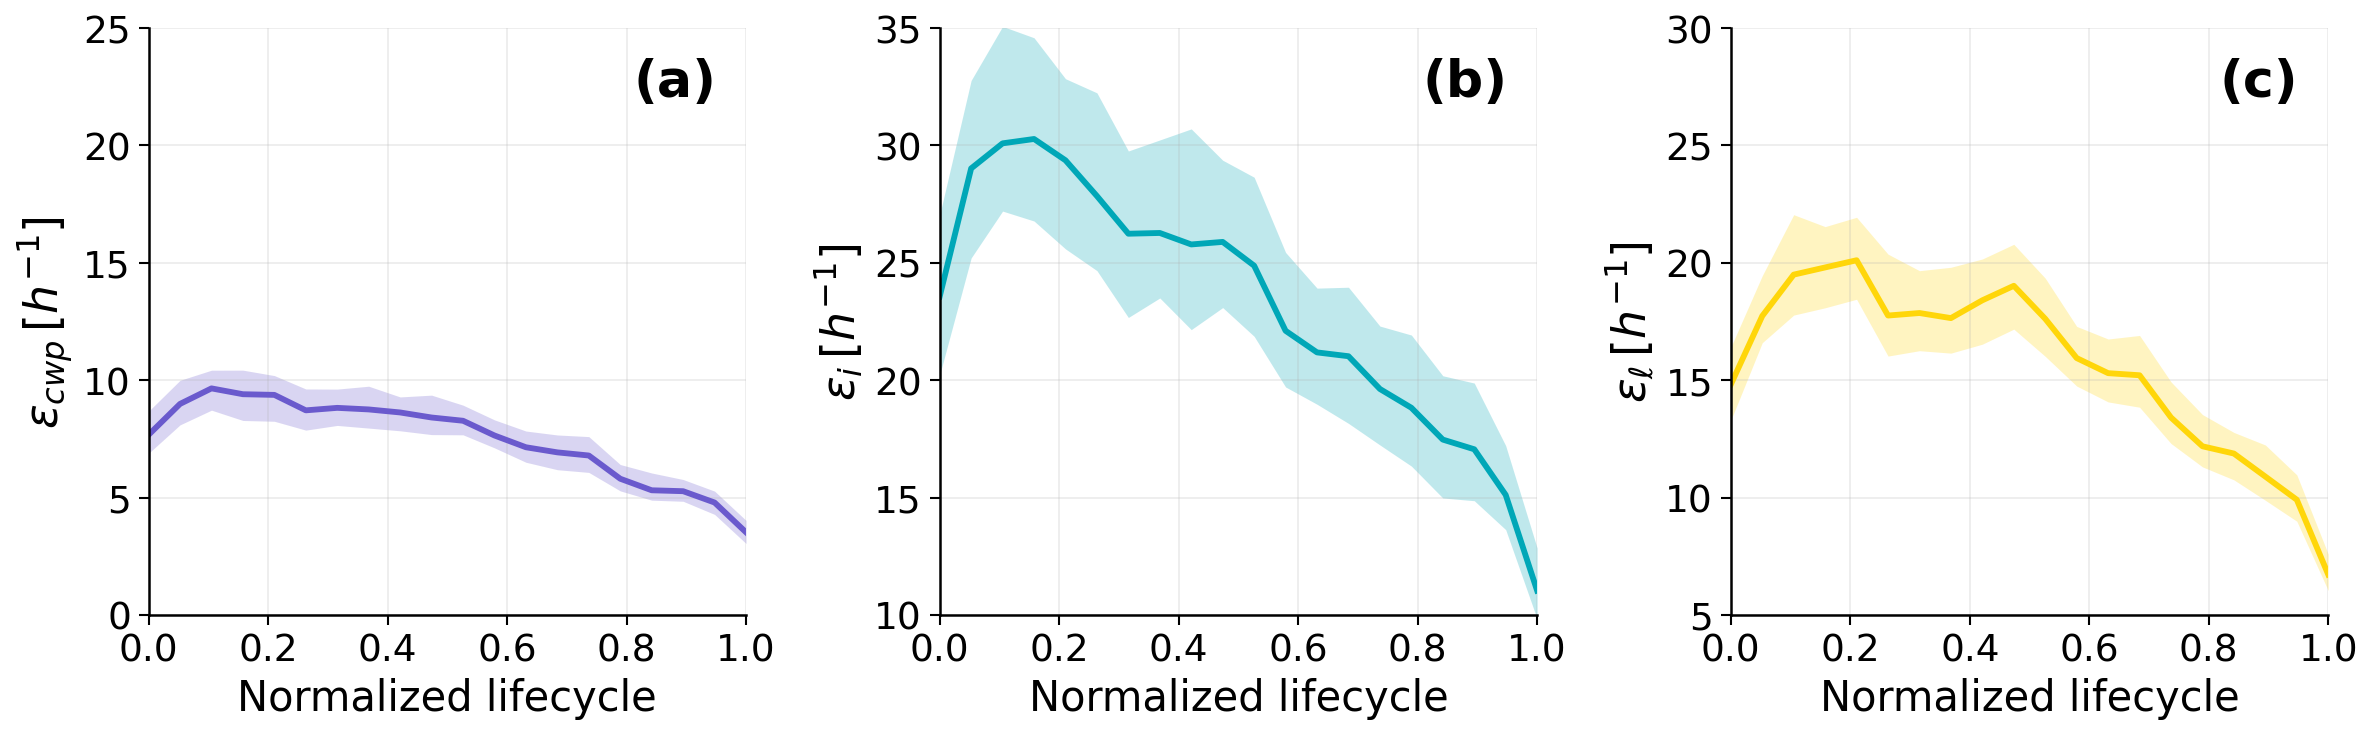

In [1]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# USER INPUTS
# ===============================
basedir_eff = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/lifecyle/"

eff_specs = [
    ("CWP", basedir_eff + "precip_efficiency_gt1hr_cwp_fromPIXEL.nc", r"$\epsilon_{cwp}$"),
    ("CIW", basedir_eff + "precip_efficiency_gt1hr_ciw_fromPIXEL.nc", r"$\epsilon_{i}$"),
    ("CLW", basedir_eff + "precip_efficiency_gt1hr_clw_fromPIXEL.nc", r"$\epsilon_{\ell}$"),
]

mcs_file        = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/Precipitation_Features/Asia_prec_features/mcs_tracks_pf_20160101.0000_20170101.0000_Asia.nc"
nbins           = 20
min_duration_hr = 4
y_norm_mode     = "none"   # options: 'none', 'max', 'first'

# ---- Bootstrap settings ----
NBOOT = 3000          # 1000–5000 is typical; 3000 is a good default
CI    = (2.5, 97.5)   # 95% CI
SEED  = 42

# ---- Figure settings ----
DPI          = 150
FIGSIZE      = (16, 5)
PANEL_COLORS = ["#6A5ACD", "#00A7B7", "#FFD60A"]
PANEL_YLABEL = [r"$\epsilon_{cwp}\,[h^{-1}]$", r"$\epsilon_{i}\,[h^{-1}]$", r"$\epsilon_{\ell}\,[h^{-1}]$"]
XLABEL       = "Normalized lifecycle"

# ---- NEW: Panel labels + y-limits ----
PANEL_TAGS = ["(a)", "(b)", "(c)"]
YLIMS = [
    (0, 25),    # subplot (a)
    (10, 35),   # subplot (b)
    (5, 30),    # subplot (c)
]

# ===============================
# LOAD MCS BASE TIME
# ===============================
mcs = xr.open_dataset(mcs_file)
bt  = mcs["base_time"].load()
time_res_hr = float(mcs.attrs.get("time_resolution_hour", 0.5))

tracks_dim, times_dim = bt.shape
target_frac = np.linspace(0, 1, nbins)

# ===============================
# FUNCTION: BUILD NORMALIZED LIFECYCLE MATRIX (nbins × ntracks)
# ===============================
def compute_lifecycle_matrix(eff_file, y_norm_mode="none"):

    eff_ds = xr.open_dataset(eff_file)
    eps = eff_ds["precip_efficiency"].load()
    eps = eps * 3600.0  # s^-1 → h^-1

    eps_arr = eps.values

    valid_bt  = (bt.values != -9999)
    valid_eps = np.isfinite(eps_arr)
    valid     = valid_bt & valid_eps

    dur_steps  = valid.sum(axis=1)
    dur_hours  = dur_steps * time_res_hr
    keep_track = dur_hours > min_duration_hr

    norm_matrix = np.full((nbins, int(keep_track.sum())), np.nan, dtype=np.float32)
    col = 0

    for i in range(tracks_dim):

        if not keep_track[i]:
            continue

        vmask = valid[i]
        if vmask.sum() < 2:
            continue

        series = eps_arr[i, vmask].astype(float)
        series = series[np.isfinite(series)]
        if series.size < 2:
            continue

        # ---- optional normalization ----
        if y_norm_mode == "max":
            m = np.nanmax(series)
            if np.isfinite(m) and m > 0:
                series = series / m
            else:
                continue

        elif y_norm_mode == "first":
            m = series[0]
            if np.isfinite(m) and m != 0:
                series = series / m
            else:
                continue

        # ---- interpolate to normalized lifecycle ----
        src_frac = np.linspace(0, 1, series.size)
        norm_matrix[:, col] = np.interp(target_frac, src_frac, series)
        col += 1

    eff_ds.close()

    # trim to filled columns
    norm_matrix = norm_matrix[:, :col]
    return norm_matrix

# ===============================
# FUNCTION: BOOTSTRAP CONFIDENCE INTERVALS ON THE MEDIAN
# ===============================
def bootstrap_median_ci(matrix, nboot=2000, ci=(2.5, 97.5), seed=42):
    """
    matrix: (nbins, ntracks)
    Returns:
      median (nbins,), ci_low (nbins,), ci_high (nbins,)
    """
    rng = np.random.default_rng(seed)

    if matrix.ndim != 2:
        raise ValueError("matrix must be 2D: (nbins, ntracks)")

    nb, nt = matrix.shape
    if nt < 5:
        raise ValueError(f"Too few tracks for bootstrap (ntracks={nt}).")

    boot_medians = np.full((nboot, nb), np.nan, dtype=float)

    for b in range(nboot):
        idx = rng.integers(0, nt, size=nt)  # resample tracks with replacement
        sample = matrix[:, idx]
        boot_medians[b, :] = np.nanmedian(sample, axis=1)

    median = np.nanmedian(matrix, axis=1)
    lo = np.nanpercentile(boot_medians, ci[0], axis=0)
    hi = np.nanpercentile(boot_medians, ci[1], axis=0)

    return median, lo, hi

# ===============================
# PROCESS ALL THREE METRICS
# ===============================
medians  = []
ci_low   = []
ci_high  = []
counts   = []  # number of valid tracks contributing per bin (for reporting)

for short_name, eff_file, _ in eff_specs:
    print(f"Processing {short_name} ...")

    mat = compute_lifecycle_matrix(eff_file, y_norm_mode=y_norm_mode)

    # track counts per bin
    counts.append(np.sum(np.isfinite(mat), axis=1))

    # bootstrap CI on median
    med, lo, hi = bootstrap_median_ci(mat, nboot=NBOOT, ci=CI, seed=SEED)

    medians.append(med)
    ci_low.append(lo)
    ci_high.append(hi)

mcs.close()

# ===============================
# PRINT SOME SUMMARY STATS (optional but useful)
# ===============================
def print_ci_summary(name, med, lo, hi, count, frac):
    peak_i = np.nanargmax(med)
    print(f"\n=== {name} ===")
    print(f"Ntracks used (approx): {int(np.nanmax(count))}")
    print(f"Median peak: {med[peak_i]:.3f} h^-1 at t={frac[peak_i]:.2f}")
    print(f"95% CI at peak: [{lo[peak_i]:.3f}, {hi[peak_i]:.3f}] h^-1")
    print(f"Median tracks per bin: {int(np.nanmedian(count))} (min={int(np.nanmin(count))}, max={int(np.nanmax(count))})")

for (name, _, _), med, lo, hi, cnt in zip(eff_specs, medians, ci_low, ci_high, counts):
    print_ci_summary(name, med, lo, hi, cnt, target_frac)

# ===============================
# 1 × 3 PLOTTING (median + 95% bootstrap CI)
# ===============================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI, sharey=False)

for i, (ax, med, lo, hi, ylabel, color) in enumerate(zip(
        axes, medians, ci_low, ci_high, PANEL_YLABEL, PANEL_COLORS)):

    ax.plot(target_frac, med, lw=2.8, color=color)
    ax.fill_between(target_frac, lo, hi, color=color, alpha=0.25, linewidth=0)

    ax.set_xlim(0, 1)
    ax.set_ylim(*YLIMS[i])

    ax.set_xlabel(XLABEL, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=22)

    # Panel tag (a), (b), (c)
    ax.text(
        0.95, 0.95, PANEL_TAGS[i],
        transform=ax.transAxes,
        fontsize=25,
        fontweight="bold",
        va="top",
        ha="right"
    )

    # light grid (optional)
    ax.grid(True, alpha=0.25)

    ax.tick_params(axis="x", labelsize=18, length=5, width=1.0)
    ax.tick_params(axis="y", labelsize=18, length=5, width=1.0)

    # remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # thicken remaining spines (publication look)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

plt.tight_layout(w_pad=1.2)

# ===============================
# SAVE
# ===============================
out_png = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_Paper_Plots/Figure9_MCS_lifecyle.png"
out_pdf = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_Paper_Plots/Figure9_MCS_lifecyle.pdf"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.savefig(out_pdf, dpi=200, bbox_inches="tight")

plt.show()
